In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import re 
import mido
import os
import shutil


# Download and organize data

In [2]:
# ! git clone https://github.com/madelinehamilton/BiMMuDa.git data/

In [3]:
# source_root = "data/BiMMuDA"
# destination = "all_midis"

# os.makedirs(destination, exist_ok=True)

# for root, dirs, files in os.walk(source_root):
#     for file in files:
#         if file.endswith(".mid"):
#             src_path = os.path.join(root, file)
#             dst_path = os.path.join(destination, file)
#             shutil.copy2(src_path, dst_path)

In [4]:

# SOURCE_DIR = "all_midis"
# DEST_DIR = "clean_monophonic_midis"

# os.makedirs(DEST_DIR, exist_ok=True)

# def is_monophonic(midi_path):
#     try:
#         midi = mido.MidiFile(midi_path)
#     except Exception:
#         return False, "corrupted"

#     notes = []
#     current_time = 0

#     for track in midi.tracks:
#         current_time = 0
#         active_notes = {}

#         for msg in track:
#             current_time += msg.time

#             if msg.type == "note_on" and msg.velocity > 0 and msg.channel != 9:
#                 active_notes[msg.note] = current_time

#             elif (msg.type == "note_off") or (msg.type == "note_on" and msg.velocity == 0):
#                 if msg.note in active_notes:
#                     start = active_notes.pop(msg.note)
#                     end = current_time
#                     notes.append((start, end))

#     if len(notes) == 0:
#         return False, "no_notes"

#     # sort by start time
#     notes.sort(key=lambda x: x[0])

#     # check overlap
#     prev_end = notes[0][1]
#     for start, end in notes[1:]:
#         if start < prev_end:
#             return False, "polyphonic"
#         prev_end = max(prev_end, end)

#     return True, "monophonic"


# print("Cleaning MIDI dataset for IDyOM...\n")

# for file in os.listdir(SOURCE_DIR):
#     if file.endswith(".mid"):
        
#         # Skip files containing "full"
#         if "full" in file.lower():
#             print(f"Skipping {file} → contains 'full'")
#             continue
        
#         path = os.path.join(SOURCE_DIR, file)
#         ok, reason = is_monophonic(path)

#         if ok:
#             shutil.copy2(path, os.path.join(DEST_DIR, file))
#         else:
#             print(f"Skipping {file} → {reason}")

# print("\nDone.")

## Load Genre Data

In [5]:
genre_df = pd.read_csv("data/BiMMuDa/metadata/bimmuda_per_song_metadata.csv")
genre_df["year_position"] = (
    genre_df["Year"].astype(str)
    + "_"
    + genre_df["Position"].astype(str).str.extract(r"(\d+)")[0].str.zfill(2)
    + genre_df["Position"].astype(str).str.extract(r"([a-zA-Z]+)")[0].fillna("")
)

genre_subset = genre_df[[
    "year_position",
    "Genre (Broad 1)",
    "Genre (Broad 2)",
    "Genre (Specific 1)",
    "Genre (Specific 2)",
    "Genre (Specific 3)"
]]

## Download the IDyOMpy Repo

In [ ]:
# ! git clone https://github.com/GuiMarion/IDyOMpy.git

# # Make a venv 
# ! python3.10 -m venv .venv
# ! source .venv/bin/activate
# ! pip install --upgrade pip 
# ! pip install -r requirements.txt

## if you have issues with requirements, check that versions match this: 
## matplotlib==3.7.2
## mido==1.3.0
## numpy==1.26.0
## pretty_midi==0.2.10
## scipy==1.12.0
## setuptools==68.0.0
## tqdm==4.65.0

## Cross Validation Trend

In [6]:
# To produce the output run this code, output will be saved in "out" folder which has been since renamed in this repo
# ! python3 IDyOM/App.py -c clean_monophonic_midis/

with open("cross_val_out/eval/data/likelihoods_cross-eval_k_fold_5_quantization_24_maxOrder_20_viewpoints_pitch_length.pickle", "rb") as f:
    cross_val_surprisal = pickle.load(f)

cross_val_df = pd.DataFrame(cross_val_surprisal).drop(columns=["info"])

In [7]:
# --- Step 1: Compute per-song means ---
song_stats = []

for song in cross_val_df.columns:
    year = int(song[:4])  # extract year from filename
    
    surprisal_vector = cross_val_df.loc[0, song]
    entropy_vector = cross_val_df.loc[1, song]
    
    mean_surprisal = np.mean(surprisal_vector)
    mean_entropy = np.mean(entropy_vector)
    
    song_stats.append({
        "song": song,
        "year": year,
        "mean_surprisal": mean_surprisal,
        "mean_entropy": mean_entropy
    })

song_df = pd.DataFrame(song_stats)

# --- Step 2: Aggregate by year ---
cross_val_yearly_avg = (
    song_df
    .groupby("year")[["mean_surprisal", "mean_entropy"]]
    .mean()
    .reset_index()
    .sort_values("year")
)

print(cross_val_yearly_avg)

    year  mean_surprisal  mean_entropy
0   1950        4.406358      3.138299
1   1951        4.781330      3.560367
2   1952        4.461024      3.403464
3   1953        4.960273      3.605045
4   1954        4.255583      3.329353
..   ...             ...           ...
70  2020        3.618874      2.931633
71  2021        3.152493      2.692932
72  2022        3.110473      2.689270
73  2023        3.499404      2.974384
74  2024        3.664309      3.016401

[75 rows x 3 columns]


In [8]:
best_fit_slopes = []

Surprisal slope: -0.0199
Entropy slope: -0.0098


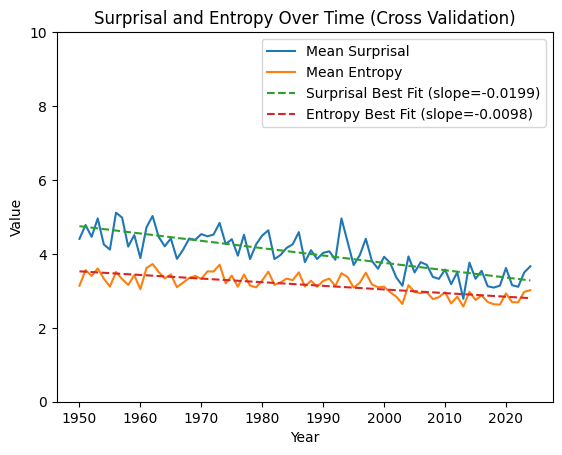

In [49]:

plt.figure()

plt.plot(cross_val_yearly_avg["year"], cross_val_yearly_avg["mean_surprisal"], label="Mean Surprisal")
plt.plot(cross_val_yearly_avg["year"], cross_val_yearly_avg["mean_entropy"], label="Mean Entropy")

years = cross_val_yearly_avg["year"]

for col, label in [("mean_surprisal", "Surprisal"), ("mean_entropy", "Entropy")]:
    coeffs = np.polyfit(years, cross_val_yearly_avg[col], deg=1)
    slope, intercept = coeffs
    best_fit = np.poly1d(coeffs)(years)
    
    plt.plot(years, best_fit, linestyle="--", label=f"{label} Best Fit (slope={slope:.4f})")
    best_fit_slopes.append({f"cross_val_{label}":slope})
    print(f"{label} slope: {slope:.4f}")
    

plt.xlabel("Year")
plt.ylabel("Value")
plt.ylim(0,10)
plt.title("Surprisal and Entropy Over Time (Cross Validation)")
plt.legend()

plt.show()

## 5 Year Lookback Trend

In [10]:
# To create these outputs, use the below command to organize midi files in respective folders:
# ! python3 organize_midis_by_5yr.py -i clean_monophonic_midis/ -o midis_by_5yr_window -w 4 -s 1

# To run the IDyOM function on these windows, run the below command 
# ! python3 run_eras_idyom.py -d midis_by_5yr_window -r 5yr_window_results

five_yr_lookback = []
all_songs_5yr_lookback = []

for start_year in range(1950, 2020):  
    end_year = start_year + 4
    folder_start = start_year + 1
    folder_end = end_year + 1

    filepath = (
        f"5yr_window_out/{folder_start}-{folder_end}/surprises/"
        f"{start_year}-{end_year}/data/"
        f"{start_year}-{end_year}_quantization_24_maxOrder_20_viewpoints_pitch_length.pickle"
    )

    with open(filepath, "rb") as f:
        data = pickle.load(f)
        
    df = pd.DataFrame(data)
    df = df.drop(columns=["info"])

    song_stats = []

    for song_segment in df.columns:
        song_segment_split = re.split('_', song_segment)
        year = int(song_segment_split[0])  
        song_id = song_segment_split[1]
        segment_id = song_segment_split[0]
        year_position = str(year) +"_" + song_id
        surprisal_vector = df.loc[0, song_segment]
        entropy_vector = df.loc[1, song_segment]
        
        mean_surprisal = np.mean(surprisal_vector)
        mean_entropy = np.mean(entropy_vector)
        
        song_stats.append({
            "song": song_segment,
            "year": year,
            "year_position": year_position,
            "mean_surprisal": mean_surprisal,
            "mean_entropy": mean_entropy,
            "lookback_window": f"{start_year}-{end_year}"
        })

    all_songs_5yr_lookback.extend(song_stats)
    
    song_df = pd.DataFrame(song_stats)

    # --- Step 2: Aggregate by year ---
    yearly_stats = (
        song_df
        .groupby("year")[["mean_surprisal", "mean_entropy"]]
        .mean()
        .reset_index()
        .sort_values("year")
    )
    
    five_yr_lookback.append(yearly_stats.iloc[-1])
    
five_yr_lookback = pd.DataFrame(five_yr_lookback)
five_yr_lookback


,year,mean_surprisal,mean_entropy
4,1955.0,4.140432,3.094362
4,1956.0,5.107264,3.549987
4,1957.0,9.522592,3.398589
4,1958.0,4.795288,3.225394
4,1959.0,4.682121,3.499601
...,...,...,...
4,2020.0,3.911545,2.721305
4,2021.0,3.366579,2.513096
4,2022.0,3.521129,2.503355
4,2023.0,3.661760,2.769175


Surprisal slope: -0.0277
Entropy slope: -0.0151


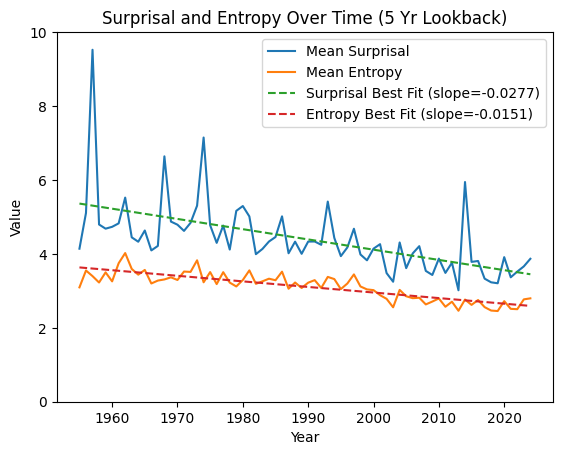

In [50]:

plt.figure()

plt.plot(five_yr_lookback["year"], five_yr_lookback["mean_surprisal"], label="Mean Surprisal")
plt.plot(five_yr_lookback["year"], five_yr_lookback["mean_entropy"], label="Mean Entropy")

years = five_yr_lookback["year"]

for col, label in [("mean_surprisal", "Surprisal"), ("mean_entropy", "Entropy")]:
    coeffs = np.polyfit(years, five_yr_lookback[col], deg=1)
    slope, intercept = coeffs
    best_fit = np.poly1d(coeffs)(years)
    
    plt.plot(years, best_fit, linestyle="--", label=f"{label} Best Fit (slope={slope:.4f})")
    best_fit_slopes.append({f"five_yr_lookback_{label}":slope})
    print(f"{label} slope: {slope:.4f}")
    

plt.xlabel("Year")
plt.ylabel("Value")
plt.ylim(0,10)
plt.title("Surprisal and Entropy Over Time (5 Yr Lookback)")
plt.legend()

plt.show()

## 10 Year Lookback Trend

In [12]:
# Run these 2 commands first to get data for this plot
# ! python3 organize_midis_by_5yr.py -i clean_monophonic_midis -o midis_by_10yr_window -w 9 -s 1
# ! python3 run_eras_idyom.py -d midis_by_10yr_window -r out/

ten_yr_lookback = []
all_songs_10yr_lookback = []

for start_year in range(1950, 2015):  
    end_year = start_year + 9
    folder_start = start_year + 1
    folder_end = end_year + 1

    filepath = (
        f"10yr_window_out/eval_{folder_end}/surprises/"
        f"{start_year}-{end_year}/data/"
        f"{start_year}-{end_year}_quantization_24_maxOrder_20_viewpoints_pitch_length.pickle"
    )

    with open(filepath, "rb") as f:
        data = pickle.load(f)
        
    df = pd.DataFrame(data)
    df = df.drop(columns=["info"])

    song_stats = []

    for song_segment in df.columns:
        song_segment_split = re.split('_', song_segment)
        year = int(song_segment_split[0])  
        song_id = song_segment_split[1]
        segment_id = song_segment_split[0]
        year_position = str(year) +"_" + song_id
        surprisal_vector = df.loc[0, song_segment]
        entropy_vector = df.loc[1, song_segment]
        
        mean_surprisal = np.mean(surprisal_vector)
        mean_entropy = np.mean(entropy_vector)
        
        song_stats.append({
            "song": song_segment,
            "year": year,
            "year_position": year_position,
            "mean_surprisal": mean_surprisal,
            "mean_entropy": mean_entropy,
            "lookback_window": f"{start_year}-{end_year}"
        })

    all_songs_10yr_lookback.extend(song_stats)
    
    song_df = pd.DataFrame(song_stats)

    # --- Step 2: Aggregate by year ---
    yearly_stats = (
        song_df
        .groupby("year")[["mean_surprisal", "mean_entropy"]]
        .mean()
        .reset_index()
        .sort_values("year")
    )
    
    ten_yr_lookback.append(yearly_stats.iloc[-1])
    
ten_yr_lookback = pd.DataFrame(ten_yr_lookback)
ten_yr_lookback
    

,year,mean_surprisal,mean_entropy
0,1960.0,4.207107,3.225023
0,1961.0,4.731308,3.711174
0,1962.0,5.424668,4.015519
0,1963.0,4.407056,3.614679
0,1964.0,4.304563,3.463503
...,...,...,...
0,2020.0,3.713925,2.767099
0,2021.0,3.168800,2.540807
0,2022.0,3.350590,2.534589
0,2023.0,3.612029,2.793525


Surprisal slope: -0.0223
Entropy slope: -0.0169


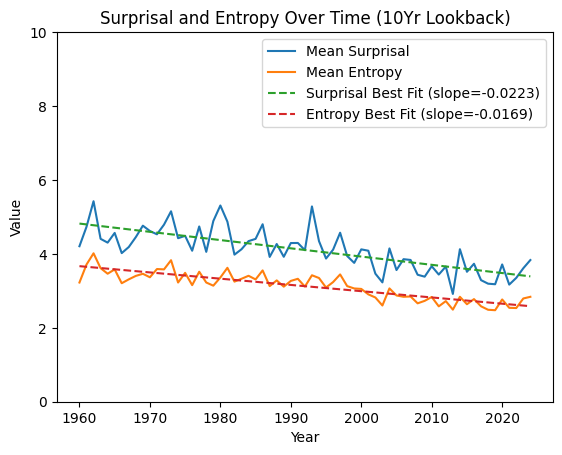

In [51]:

plt.figure()

plt.plot(ten_yr_lookback["year"], ten_yr_lookback["mean_surprisal"], label="Mean Surprisal")
plt.plot(ten_yr_lookback["year"], ten_yr_lookback["mean_entropy"], label="Mean Entropy")

years = ten_yr_lookback["year"]

for col, label in [("mean_surprisal", "Surprisal"), ("mean_entropy", "Entropy")]:
    coeffs = np.polyfit(years, ten_yr_lookback[col], deg=1)
    slope, intercept = coeffs
    best_fit = np.poly1d(coeffs)(years)
    
    plt.plot(years, best_fit, linestyle="--", label=f"{label} Best Fit (slope={slope:.4f})")
    best_fit_slopes.append({f"ten_yr_lookback_{label}":slope})
    print(f"{label} slope: {slope:.4f}")
    

plt.xlabel("Year")
plt.ylabel("Value")
plt.ylim(0,10)
plt.title("Surprisal and Entropy Over Time (10Yr Lookback)")
plt.legend()

plt.show()

In [14]:
# Combine all windows into one dataframe
all_songs_10yr_lookback = pd.DataFrame(all_songs_10yr_lookback)

# Merge with genre data on shared key
merged_all_songs_10yr_lookback = pd.merge(
    all_songs_10yr_lookback,
    genre_subset,
    on="year_position",
    how="left"
)

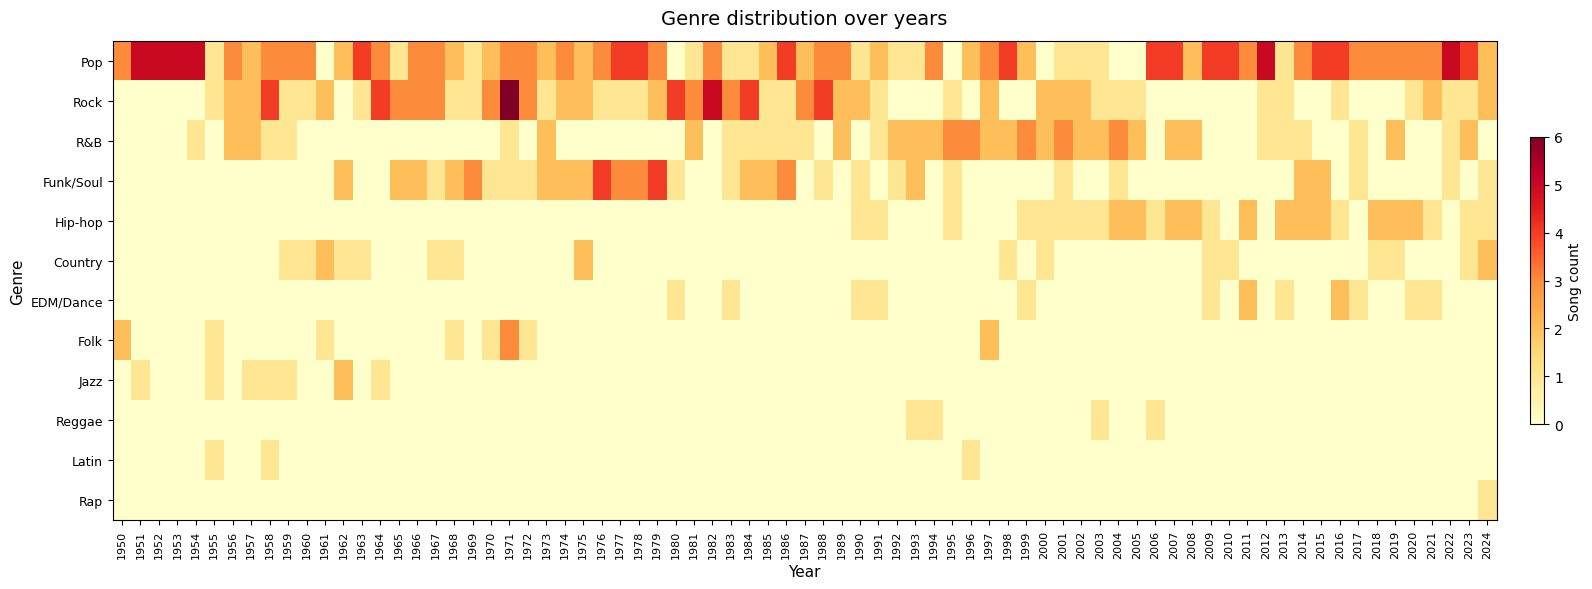

In [56]:
genre_cols = [
    "Genre (Broad 1)", "Genre (Broad 2)",
    # "Genre (Specific 1)", "Genre (Specific 2)", "Genre (Specific 3)"
]

# Melt to long format, drop NaN genres
df_long = merged_cross_val_df.melt(
    id_vars=["year_position", "year"],
    value_vars=genre_cols,
    var_name="genre_col",
    value_name="genre"
).dropna(subset=["genre"])

# Count songs per genre per year (deduplicate same song counted twice
# for the same genre via different columns)
df_long = df_long.drop_duplicates(subset=["year_position", "genre"])
heatmap_data = (
    df_long.groupby(["genre", "year"])
    .size()
    .reset_index(name="count")
)

# Pivot to genre x year matrix
pivot = heatmap_data.pivot(index="genre", columns="year", values="count").fillna(0)

# Sort genres by total count descending so busiest genres are at the top
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(18, max(6, len(pivot) * 0.45)))

im = ax.imshow(
    pivot.values,
    aspect="auto",
    cmap="YlOrRd",
    interpolation="nearest"
)

# Axes labels
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)

# Colorbar
cbar = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label("Song count", fontsize=10)

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Genre", fontsize=11)
ax.set_title("Genre distribution over years", fontsize=14, pad=12)

plt.tight_layout()
plt.show()

In [16]:
cross_val_df = cross_val_df.T.reset_index()
cross_val_df.columns = ["year_position_raw", "surprisal", "entropy"]

cross_val_df["year"] = cross_val_df["year_position_raw"].str.rsplit("_", n=0).str[0]
cross_val_df["year_position"] = cross_val_df["year_position_raw"].str.rsplit("_", n=1).str[0]
merged_cross_val_df = pd.merge(cross_val_df, genre_subset, on="year_position", how="left")
merged_cross_val_df.drop(index=merged_cross_val_df.index[-1],axis=0,inplace=True)

# Compute per-song means and map back to merged_cross_val_df
merged_cross_val_df["mean_surprisal"] = merged_cross_val_df["surprisal"].apply(np.mean)
merged_cross_val_df["mean_entropy"] = merged_cross_val_df["entropy"].apply(np.mean)

In [54]:
min_data_points = 10

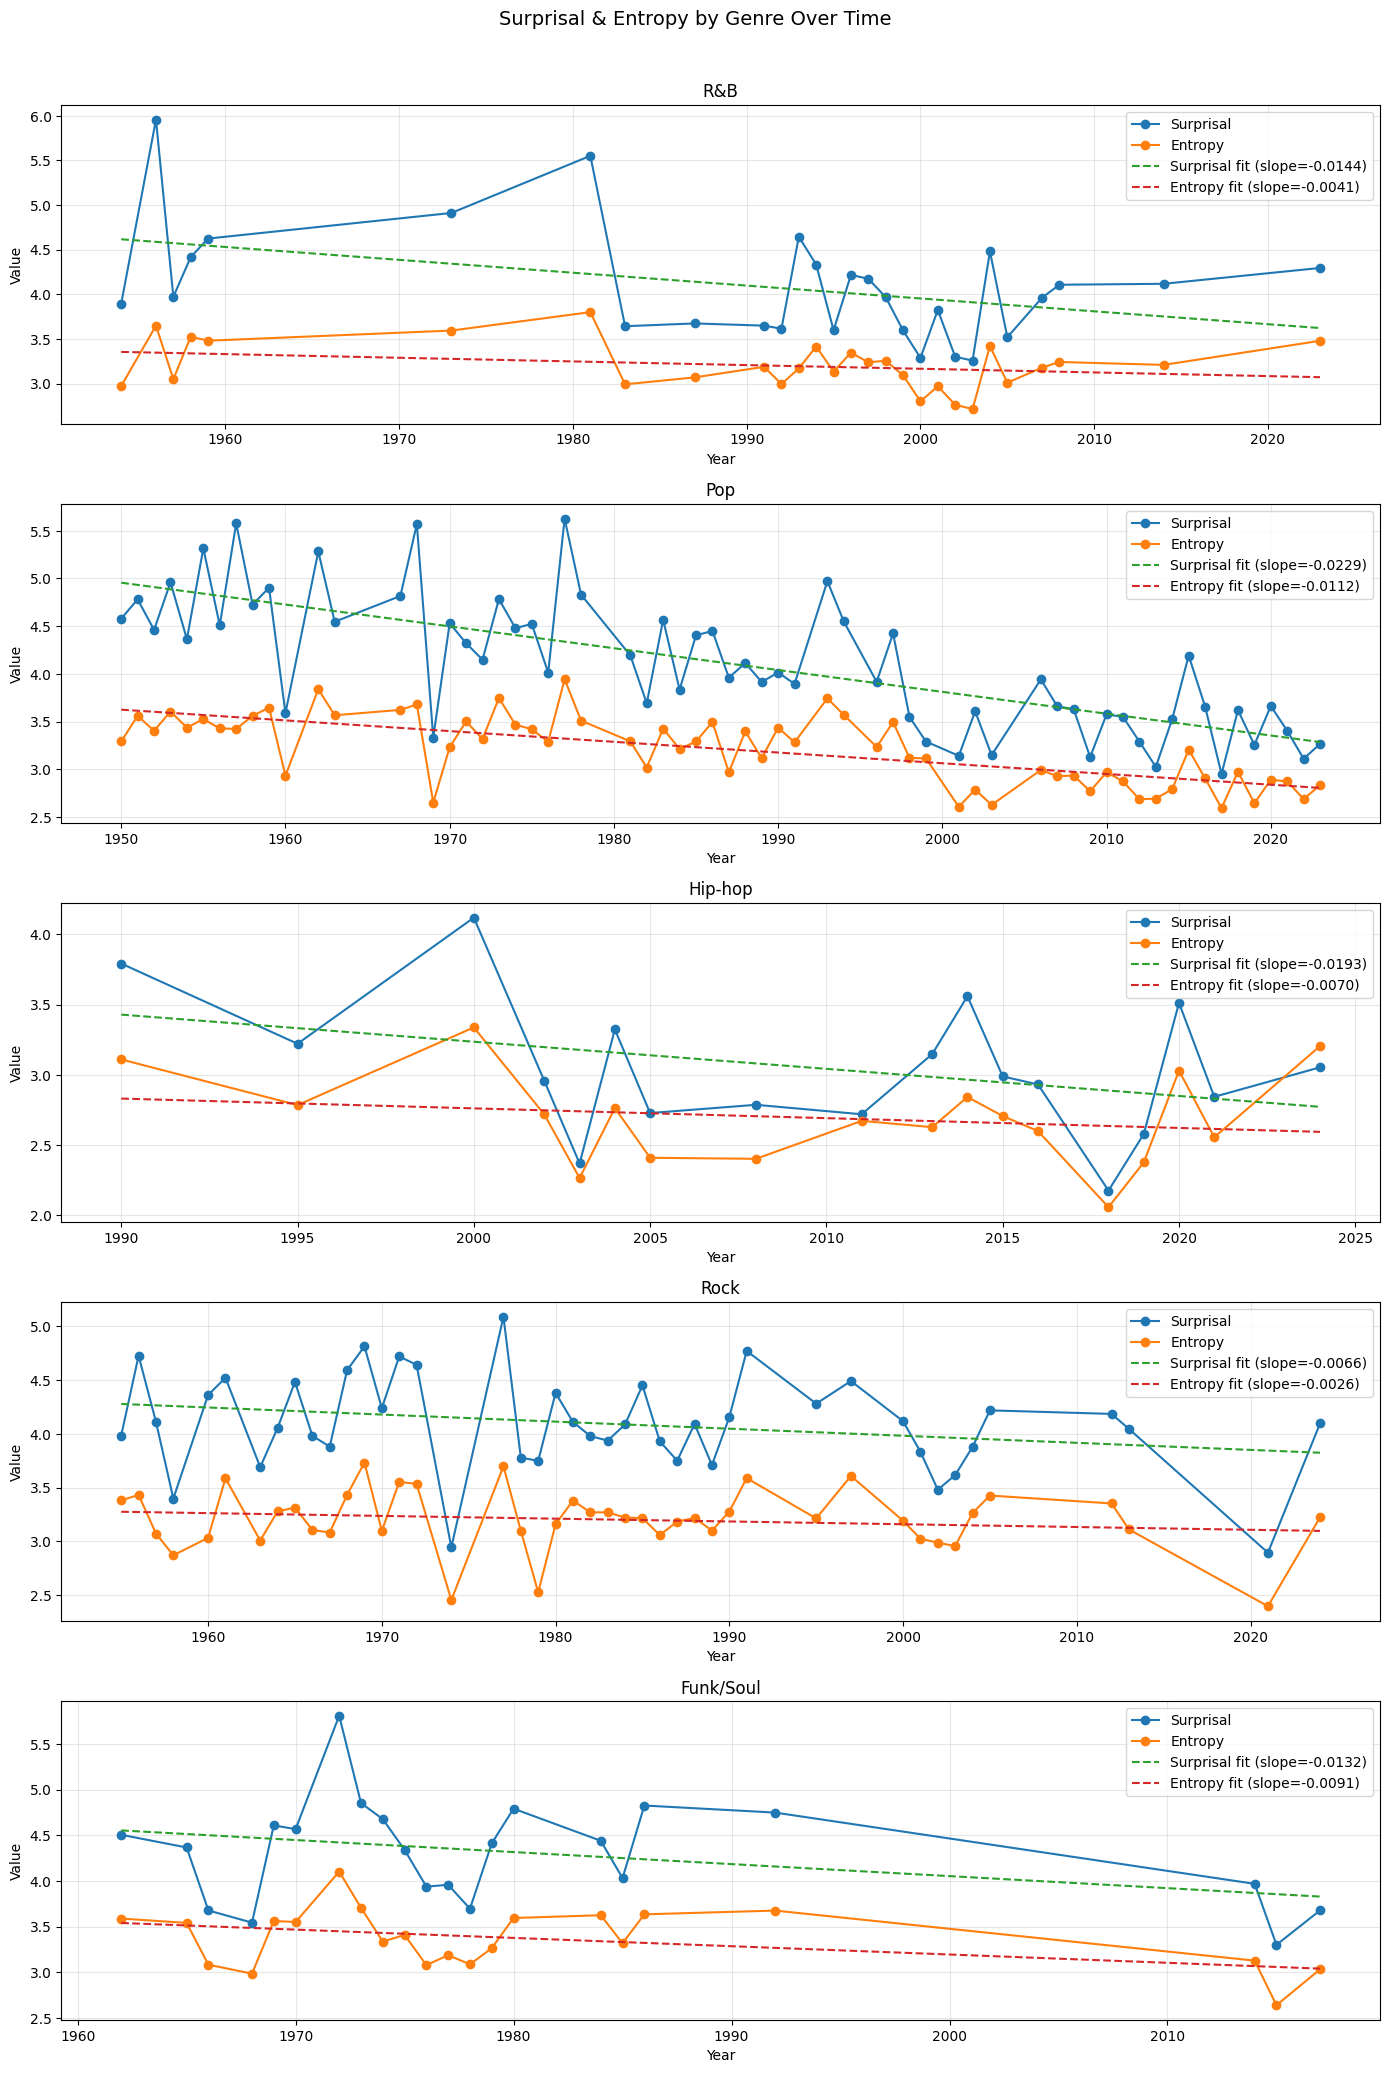

In [55]:
merged_cross_val_df["Genre (Broad 1)"] = merged_cross_val_df["Genre (Broad 1)"].str.strip()
genres = merged_cross_val_df["Genre (Broad 1)"].dropna().unique()

# Pre-filter to only genres with enough data
valid_genres = []
for genre in genres:
    genre_df = merged_cross_val_df[merged_cross_val_df["Genre (Broad 1)"] == genre].copy()
    genre_df["year"] = genre_df["year"].astype(int)
    yearly = genre_df.groupby("year")[["mean_surprisal", "mean_entropy"]].mean().reset_index()
    if len(yearly) >= min_data_points:
        valid_genres.append(genre)

fig, axes = plt.subplots(len(valid_genres), 1, figsize=(14, 4 * len(valid_genres)))

for ax, genre in zip(axes, genres):
    genre_df = merged_cross_val_df[merged_cross_val_df["Genre (Broad 1)"] == genre].copy()
    genre_df["year"] = genre_df["year"].astype(int)
    yearly = (
        genre_df.groupby("year")[["mean_surprisal", "mean_entropy"]]
        .mean()
        .reset_index()
        .sort_values("year")
    )

    # Skip entirely if too few data points
    if len(yearly) <= min_data_points:
        ax.set_visible(False)  # hide the empty axes
        continue

    ax.plot(yearly["year"], yearly["mean_surprisal"], label="Surprisal", marker="o")
    ax.plot(yearly["year"], yearly["mean_entropy"], label="Entropy", marker="o")

    years = yearly["year"]
    for col, label in [("mean_surprisal", "Surprisal"), ("mean_entropy", "Entropy")]:
        coeffs = np.polyfit(years, yearly[col], deg=1)
        slope = coeffs[0]
        best_fit = np.poly1d(coeffs)(years)
        ax.plot(years, best_fit, linestyle="--", label=f"{label} fit (slope={slope:.4f})")
        best_fit_slopes.append({f"cross_val_{genre}_{label}": slope})

    ax.set_title(genre)
    ax.set_ylabel("Value")
    ax.set_xlabel("Year")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Surprisal & Entropy by Genre Over Time", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [19]:
all_songs_5yr_lookback = pd.DataFrame(all_songs_5yr_lookback)
merged_all_songs_5yr_lookback = pd.merge(all_songs_5yr_lookback, genre_subset, on="year_position", how="left")
merged_all_songs_5yr_lookback.drop(index=merged_all_songs_5yr_lookback.index[-1],axis=0,inplace=True)


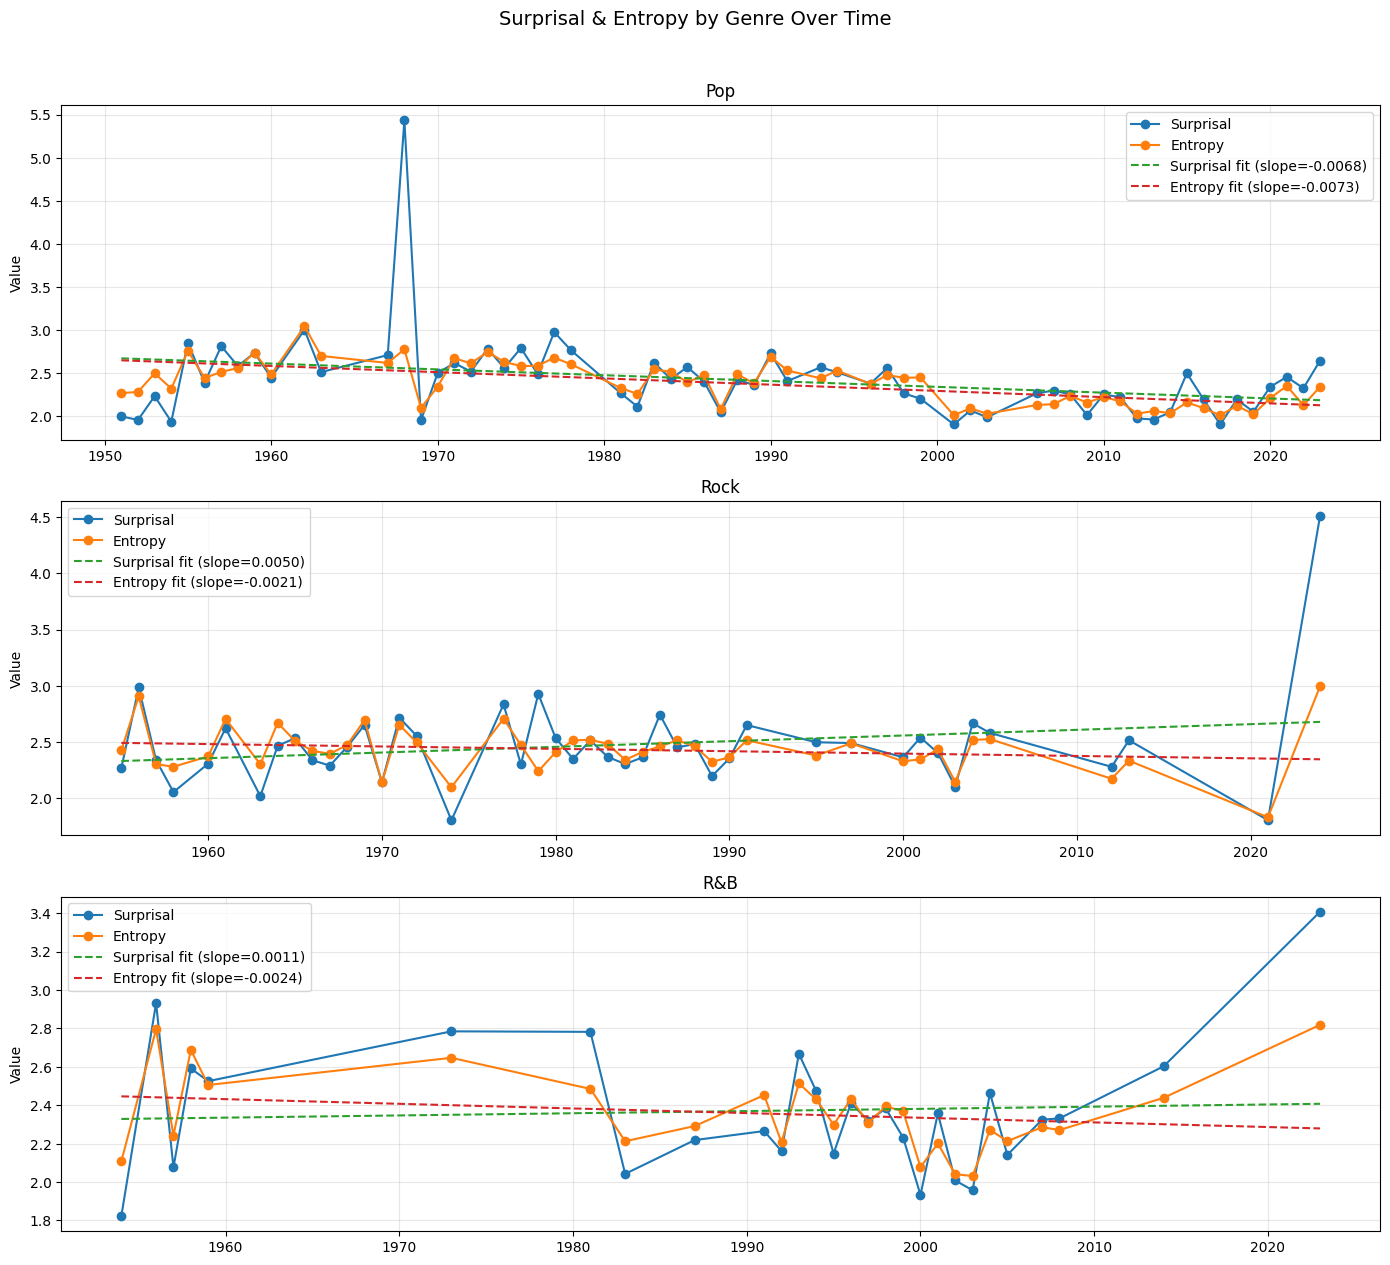

In [20]:
merged_all_songs_5yr_lookback["Genre (Broad 1)"] = merged_all_songs_5yr_lookback["Genre (Broad 1)"].str.strip()
genres = merged_all_songs_5yr_lookback["Genre (Broad 1)"].dropna().unique()

# Pre-filter to only genres with enough data
valid_genres = []
for genre in genres:
    genre_df = merged_cross_val_df[merged_cross_val_df["Genre (Broad 1)"] == genre].copy()
    genre_df["year"] = genre_df["year"].astype(int)
    yearly = genre_df.groupby("year")[["mean_surprisal", "mean_entropy"]].mean().reset_index()
    if len(yearly) >= min_data_points:
        valid_genres.append(genre)

fig, axes = plt.subplots(len(valid_genres), 1, figsize=(14, 4 * len(valid_genres)))

for ax, genre in zip(axes, genres):
    genre_df = merged_all_songs_5yr_lookback[merged_all_songs_5yr_lookback["Genre (Broad 1)"] == genre].copy()
    genre_df["year"] = genre_df["year"].astype(int)  # <-- add this
    yearly = (
        genre_df.groupby("year")[["mean_surprisal", "mean_entropy"]]
        .mean()
        .reset_index()
        .sort_values("year")
    )

    # Skip entirely if too few data points
    if len(yearly) < min_data_points:
        ax.set_visible(False)  # hide the empty axes
        continue

    ax.plot(yearly["year"], yearly["mean_surprisal"], label="Surprisal", marker="o")
    ax.plot(yearly["year"], yearly["mean_entropy"], label="Entropy", marker="o")
    
    # Lines of best fit
    years = yearly["year"]
    for col, label in [("mean_surprisal", "Surprisal"), ("mean_entropy", "Entropy")]:
        coeffs = np.polyfit(years, yearly[col], deg=1)
        slope = coeffs[0]
        best_fit = np.poly1d(coeffs)(years)
        ax.plot(years, best_fit, linestyle="--", label=f"{label} fit (slope={slope:.4f})")
        best_fit_slopes.append({f"five_yr_lookback_{genre}_{label}":slope})    

    ax.set_title(genre)
    ax.set_ylabel("Value")
    ax.legend()
    ax.grid(True, alpha=0.3)
    
plt.suptitle("Surprisal & Entropy by Genre Over Time", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [21]:
merged_all_songs_10yr_lookback = pd.DataFrame(merged_all_songs_10yr_lookback)
merged_all_songs_10yr_lookback.drop(index=merged_all_songs_10yr_lookback.index[-1],axis=0,inplace=True)

merged_all_songs_10yr_lookback


,song,year,year_position,mean_surprisal,mean_entropy,lookback_window,Genre (Broad 1),Genre (Broad 2),Genre (Specific 1),Genre (Specific 2),Genre (Specific 3)
0,1960_02_2,1960,1960_02,4.386099,3.535712,1950-1959,Country,NaN,Nashville Sound,NaN,NaN
1,1960_02_1,1960,1960_02,4.783575,3.654825,1950-1959,Country,NaN,Nashville Sound,NaN,NaN
2,1960_04_2,1960,1960_04,4.520644,3.164254,1950-1959,Rock,NaN,Rockabilly,NaN,NaN
3,1960_04_1,1960,1960_04,4.134072,3.041165,1950-1959,Rock,NaN,Rockabilly,NaN,NaN
4,1960_01_3,1960,1960_01,4.513192,3.553766,1950-1959,Pop,NaN,Easy listening,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1029,2024_01_3,2024,2024_01,2.924557,2.504715,2014-2023,Rock,Funk/Soul,NaN,NaN,NaN
1030,2024_01_1,2024,2024_01,4.141924,2.927514,2014-2023,Rock,Funk/Soul,NaN,NaN,NaN
1031,2024_03_3,2024,2024_03,4.999456,3.011176,2014-2023,Rock,Pop,Pop-rock,Alternative rock,NaN
1032,2024_03_2,2024,2024_03,5.211509,3.381883,2014-2023,Rock,Pop,Pop-rock,Alternative rock,NaN


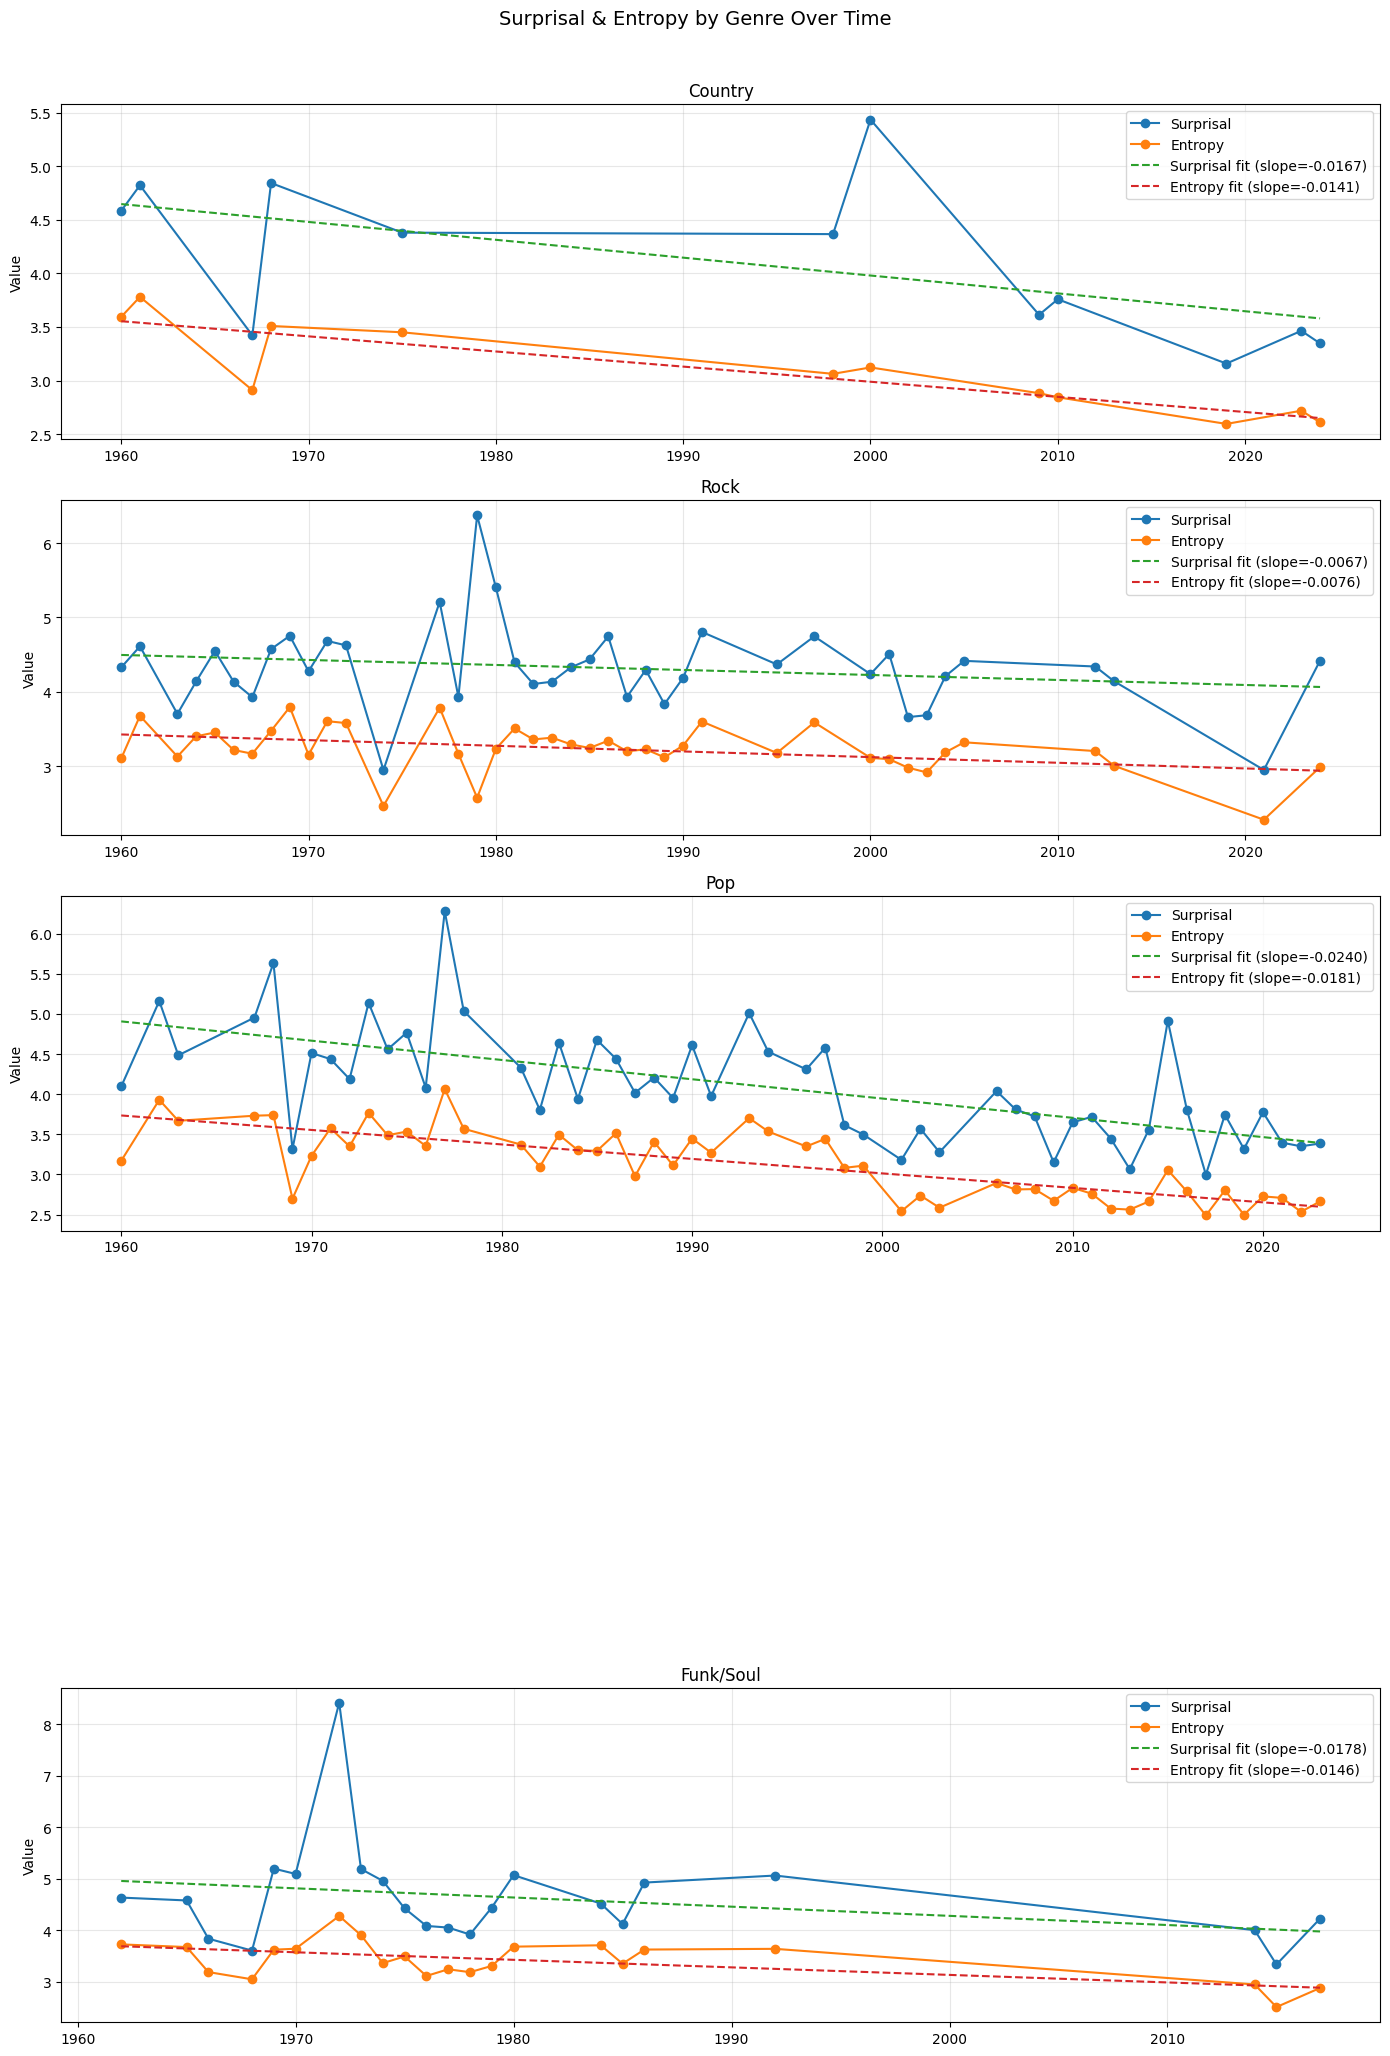

In [22]:
merged_all_songs_10yr_lookback["Genre (Broad 1)"] = merged_all_songs_10yr_lookback["Genre (Broad 1)"].str.strip()
genres = merged_all_songs_10yr_lookback["Genre (Broad 1)"].dropna().unique()

# Pre-filter to only genres with enough data
valid_genres = []
for genre in genres:
    genre_df = merged_all_songs_10yr_lookback[merged_all_songs_10yr_lookback["Genre (Broad 1)"] == genre].copy()
    genre_df["year"] = genre_df["year"].astype(int)
    yearly = genre_df.groupby("year")[["mean_surprisal", "mean_entropy"]].mean().reset_index()
    if len(yearly) >= min_data_points:
        valid_genres.append(genre)

fig, axes = plt.subplots(len(valid_genres), 1, figsize=(14, 4 * len(valid_genres)))

for ax, genre in zip(axes, genres):
    genre_df = merged_all_songs_10yr_lookback[merged_all_songs_10yr_lookback["Genre (Broad 1)"] == genre].copy()
    genre_df["year"] = genre_df["year"].astype(int)
    yearly = (
        genre_df.groupby("year")[["mean_surprisal", "mean_entropy"]]
        .mean()
        .reset_index()
        .sort_values("year")
    )

    # Skip entirely if too few data points
    if len(yearly) < min_data_points:
        ax.set_visible(False)  # hide the empty axes
        continue

    ax.plot(yearly["year"], yearly["mean_surprisal"], label="Surprisal", marker="o")
    ax.plot(yearly["year"], yearly["mean_entropy"], label="Entropy", marker="o")

    years = yearly["year"]
    for col, label in [("mean_surprisal", "Surprisal"), ("mean_entropy", "Entropy")]:
        coeffs = np.polyfit(years, yearly[col], deg=1)
        slope = coeffs[0]
        best_fit = np.poly1d(coeffs)(years)
        ax.plot(years, best_fit, linestyle="--", label=f"{label} fit (slope={slope:.4f})")
        best_fit_slopes.append({f"ten_yr_lookback_{genre}_{label}": slope})

    ax.set_title(genre)
    ax.set_ylabel("Value")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Surprisal & Entropy by Genre Over Time", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [23]:
# Flatten list of single-key dicts into one dict
slopes = {k: v for d in best_fit_slopes for k, v in d.items()}

rows = []
for key, slope in slopes.items():
    # Determine period
    if key.startswith("cross_val_"):
        period = "cross_val"
        remainder = key[len("cross_val_"):]
    elif key.startswith("five_yr_lookback_"):
        period = "five_yr_lookback"
        remainder = key[len("five_yr_lookback_"):]
    elif key.startswith("ten_yr_lookback_"):
        period = "ten_yr_lookback"
        remainder = key[len("ten_yr_lookback_"):]
    else:
        print(f"Skipping unrecognized key: {key}")
        continue

    # If remainder is just the metric (no genre)
    if remainder.strip() in ("Surprisal", "Entropy"):
        metric = remainder.strip()
        genre = None
    else:
        last_underscore = remainder.rfind("_")
        if last_underscore == -1:
            print(f"Skipping malformed remainder: {remainder}")
            continue
        metric = remainder[last_underscore + 1:].strip()
        genre = remainder[:last_underscore].strip() or None

        if metric not in ("Surprisal", "Entropy"):
            print(f"Skipping unrecognized metric '{metric}' in key: {key}")
            continue

    rows.append({"period": period, "genre": genre, "metric": metric, "slope": slope})

df = pd.DataFrame(rows)

In [24]:
# --- Table 1: Overall slopes by time period (no genre) ---
overall = df[df["genre"].isna()].pivot(index="period", columns="metric", values="slope")
overall.index = ["Cross Val", "5yr Lookback", "10yr Lookback"]
print("=== Overall Slopes by Time Period ===")
print(overall.round(4))

=== Overall Slopes by Time Period ===
metric         Entropy  Surprisal
Cross Val      -0.0098    -0.0199
5yr Lookback   -0.0151    -0.0277
10yr Lookback  -0.0169    -0.0223


In [25]:
# --- Table 2: Per-genre slopes, one table per time period ---
genre_df = df[df["genre"].notna()]

for period in ["cross_val", "five_yr_lookback", "ten_yr_lookback"]:
    subset = (
        genre_df[genre_df["period"] == period]
        .groupby(["genre", "metric"])["slope"]
        .mean()
        .reset_index()
        .pivot(index="genre", columns="metric", values="slope")
    )
    
    label = {"cross_val": "Cross Val", "five_yr_lookback": "5yr Lookback", "ten_yr_lookback": "10yr Lookback"}[period]
    print(f"\n=== {label}: Slopes by Genre ===")
    print(subset.round(4))


=== Cross Val: Slopes by Genre ===
metric     Entropy  Surprisal
genre                        
Funk/Soul  -0.0091    -0.0132
Hip-hop    -0.0070    -0.0193
Pop        -0.0112    -0.0229
R&B        -0.0041    -0.0144
Rock       -0.0026    -0.0066

=== 5yr Lookback: Slopes by Genre ===
metric  Entropy  Surprisal
genre                     
Pop     -0.0073    -0.0068
R&B     -0.0024     0.0011
Rock    -0.0021     0.0050

=== 10yr Lookback: Slopes by Genre ===
metric     Entropy  Surprisal
genre                        
Country    -0.0141    -0.0167
Funk/Soul  -0.0146    -0.0178
Pop        -0.0181    -0.0240
Rock       -0.0076    -0.0067


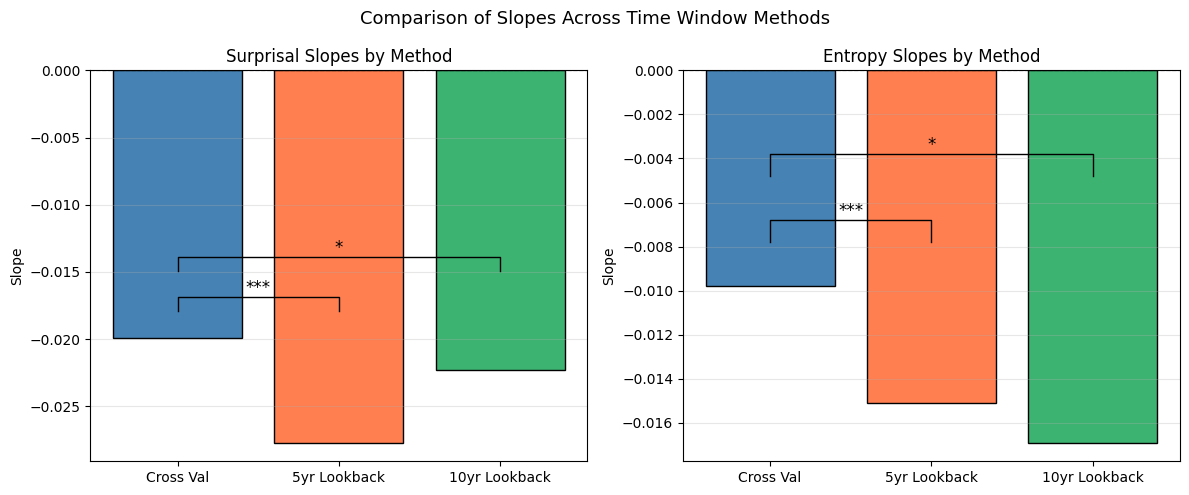

In [26]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np


results = {}
for metric, col in [("Surprisal", "mean_surprisal"), ("Entropy", "mean_entropy")]:
    cv = merged_cross_val_df[col].values
    five = merged_all_songs_5yr_lookback[col].values
    ten = merged_all_songs_10yr_lookback[col].values

    # Align lengths by trimming to shortest
    min_len = min(len(cv), len(five), len(ten))
    cv, five, ten = cv[:min_len], five[:min_len], ten[:min_len]

    t_5v_cv, p_5v_cv = stats.ttest_rel(five, cv)
    t_10v_cv, p_10v_cv = stats.ttest_rel(ten, cv)

    results[metric] = {
        "5yr_vs_cv": p_5v_cv,
        "10yr_vs_cv": p_10v_cv
    }

def sig_stars(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "ns"

# --- Bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

slopes_data = {
    "Surprisal": {"Cross Val": -0.0199, "5yr Lookback": -0.0277, "10yr Lookback": -0.0223},
    "Entropy":   {"Cross Val": -0.0098, "5yr Lookback": -0.0151, "10yr Lookback": -0.0169}
}

for ax, metric in zip(axes, ["Surprisal", "Entropy"]):
    methods = ["Cross Val", "5yr Lookback", "10yr Lookback"]
    values = [slopes_data[metric][m] for m in methods]
    colors = ["steelblue", "coral", "mediumseagreen"]
    bars = ax.bar(methods, values, color=colors, edgecolor="black")

    # Add significance annotations
    y_max = max(values) + 0.002
    bar_height = 0.001

    for i, (key, ref_idx) in enumerate([("5yr_vs_cv", 0), ("10yr_vs_cv", 0)]):
        p = results[metric][key]
        stars = sig_stars(p)
        comp_idx = i + 1
        x1, x2 = ref_idx, comp_idx
        y = y_max + i * 0.003
        ax.plot([x1, x1, x2, x2], [y, y + bar_height, y + bar_height, y], "k-", linewidth=1)
        ax.text((x1 + x2) / 2, y + bar_height, stars, ha="center", va="bottom", fontsize=12)

    ax.set_title(f"{metric} Slopes by Method")
    ax.set_ylabel("Slope")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Comparison of Slopes Across Time Window Methods", fontsize=13)
plt.tight_layout()
plt.show()

In [31]:
results

{'Surprisal': {'5yr_vs_cv': 7.320969516218328e-84,
  '10yr_vs_cv': 0.03293358678708238},
 'Entropy': {'5yr_vs_cv': 2.1087967639778205e-96,
  '10yr_vs_cv': 0.04347104681368423}}

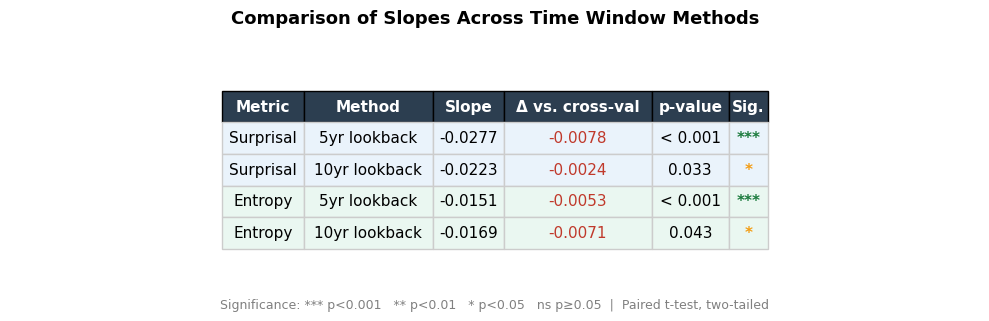

In [30]:
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# --- Your existing p-value computation ---
results = {}
for metric, col in [("Surprisal", "mean_surprisal"), ("Entropy", "mean_entropy")]:
    cv = merged_cross_val_df[col].values
    five = merged_all_songs_5yr_lookback[col].values
    ten = merged_all_songs_10yr_lookback[col].values

    min_len = min(len(cv), len(five), len(ten))
    cv, five, ten = cv[:min_len], five[:min_len], ten[:min_len]

    t_5v_cv, p_5v_cv = stats.ttest_rel(five, cv)
    t_10v_cv, p_10v_cv = stats.ttest_rel(ten, cv)

    results[metric] = {
        "5yr_vs_cv": p_5v_cv,
        "10yr_vs_cv": p_10v_cv
    }

def sig_stars(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "ns"

def fmt_p(p):
    return "< 0.001" if p < 0.001 else f"{p:.3f}"

slopes_data = {
    "Surprisal": {"Cross-val": -0.0199, "5yr lookback": -0.0277, "10yr lookback": -0.0223},
    "Entropy":   {"Cross-val": -0.0098, "5yr lookback": -0.0151, "10yr lookback": -0.0169}
}

# --- Build table data ---
rows = []
for metric in ["Surprisal", "Entropy"]:
    cv_slope = slopes_data[metric]["Cross-val"]
    for method, key in [("5yr lookback", "5yr_vs_cv"), ("10yr lookback", "10yr_vs_cv")]:
        slope = slopes_data[metric][method]
        p = results[metric][key]
        diff = slope - cv_slope
        rows.append([
            metric,
            method,
            f"{slope:.4f}",
            f"{diff:+.4f}",
            fmt_p(p),
            sig_stars(p)
        ])

col_labels = ["Metric", "Method", "Slope", "Δ vs. cross-val", "p-value", "Sig."]

# --- Plot table ---
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.axis("off")

table = ax.table(
    cellText=rows,
    colLabels=col_labels,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.8)

# Style header
for col in range(len(col_labels)):
    cell = table[0, col]
    cell.set_facecolor("#2c3e50")
    cell.set_text_props(color="white", fontweight="bold")

# Style rows
row_colors = {"Surprisal": "#eaf3fb", "Entropy": "#eaf7f1"}
sig_colors = {"***": "#1a7a3c", "**": "#2ecc71", "*": "#f39c12", "ns": "#aaaaaa"}

for i, row in enumerate(rows):
    metric = row[0]
    stars = row[5]
    bg = row_colors[metric]

    for col in range(len(col_labels)):
        cell = table[i + 1, col]
        cell.set_facecolor(bg)
        cell.set_edgecolor("#cccccc")

        if col == 5:  # Sig. column
            cell.set_text_props(color=sig_colors[stars], fontweight="bold")
        elif col == 3:  # Δ column — color by direction
            val = float(row[3])
            cell.set_text_props(color="#c0392b" if val < 0 else "#27ae60")

# Wider columns
table.auto_set_column_width([0, 1, 2, 3, 4, 5])

# Legend
legend_text = "Significance: *** p<0.001   ** p<0.01   * p<0.05   ns p≥0.05  |  Paired t-test, two-tailed"
fig.text(0.5, 0.02, legend_text, ha="center", fontsize=9, color="gray")

plt.title("Comparison of Slopes Across Time Window Methods", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

# Appendix 

## Visualize genre clusters 

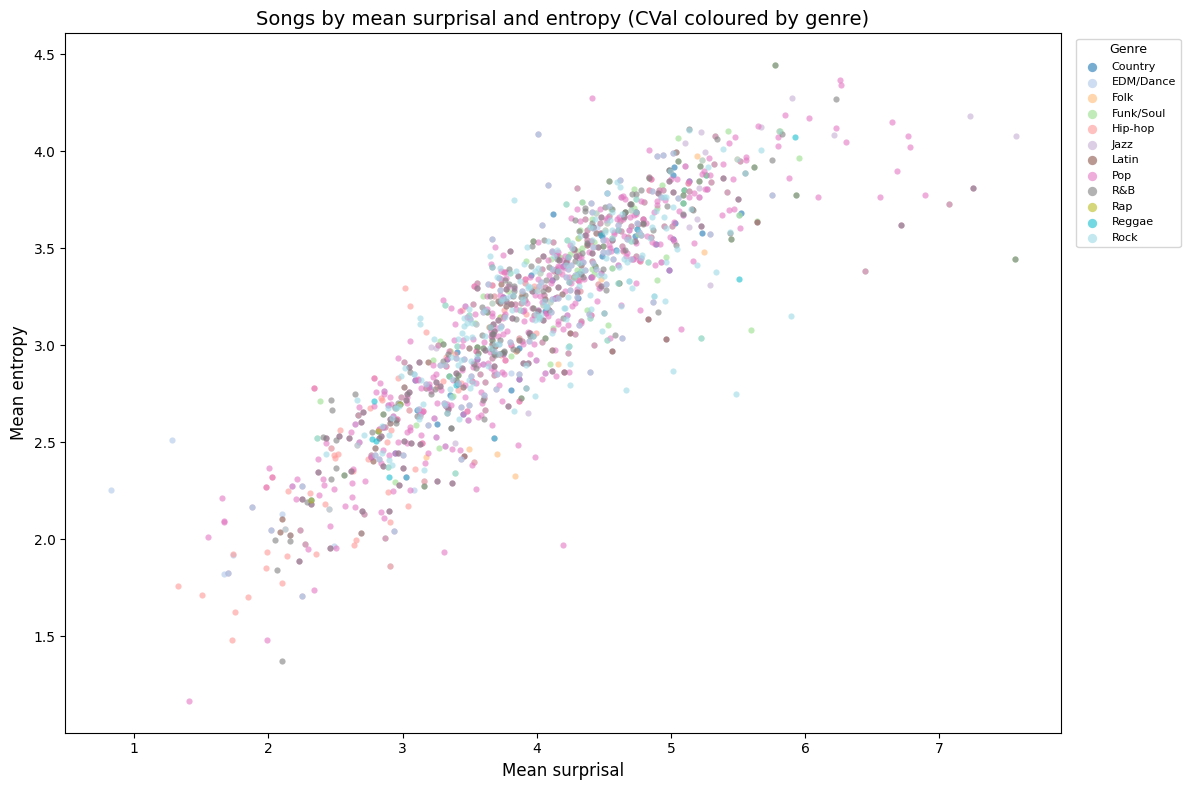

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

genre_cols = [
    "Genre (Broad 1)", "Genre (Broad 2)",
    # "Genre (Specific 1)", "Genre (Specific 2)", "Genre (Specific 3)"
]

# Melt to long format so each song-genre pair is one row, drop NaN genres
df_long = merged_cross_val_df.melt(
    id_vars=["year_position", "mean_surprisal", "mean_entropy"],
    value_vars=genre_cols,
    var_name="genre_col",
    value_name="genre"
).dropna(subset=["genre"])

# Get sorted unique genres and assign a color to each
unique_genres = sorted(df_long["genre"].unique())
cmap = plt.get_cmap("tab20", len(unique_genres))
genre_color = {genre: cmap(i) for i, genre in enumerate(unique_genres)}

fig, ax = plt.subplots(figsize=(12, 8))

# Plot each genre as its own layer so legend is clean
for genre in unique_genres:
    subset = df_long[df_long["genre"] == genre]
    ax.scatter(
        subset["mean_surprisal"],
        subset["mean_entropy"],
        color=genre_color[genre],
        label=genre,
        alpha=0.6,
        s=20,
        linewidths=0
    )

ax.set_xlabel("Mean surprisal", fontsize=12)
ax.set_ylabel("Mean entropy", fontsize=12)
ax.set_title("Songs by mean surprisal and entropy (CVal coloured by genre)", fontsize=14)

legend = ax.legend(
    title="Genre",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    fontsize=8,
    title_fontsize=9,
    frameon=True,
    markerscale=1.5
)

plt.tight_layout()
plt.show()


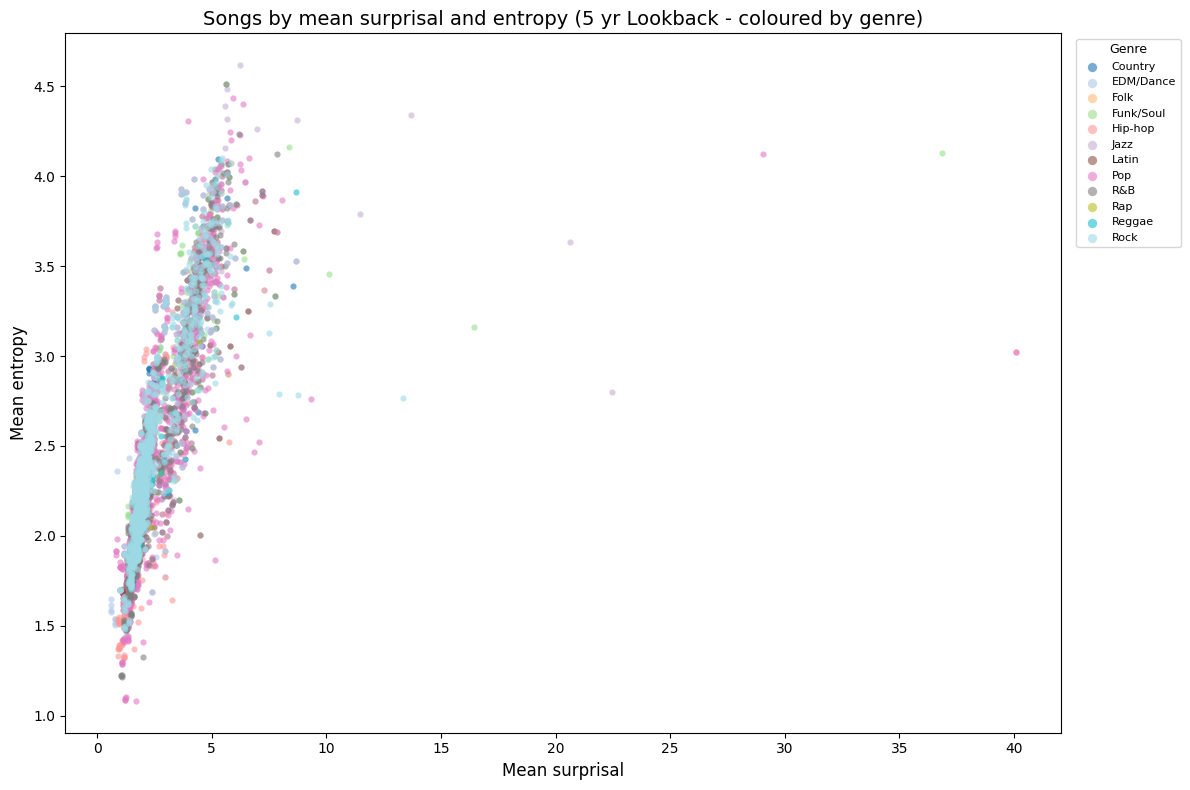

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

genre_cols = [
    "Genre (Broad 1)", "Genre (Broad 2)",
    # "Genre (Specific 1)", "Genre (Specific 2)", "Genre (Specific 3)"
]

# Melt to long format so each song-genre pair is one row, drop NaN genres
df_long = merged_all_songs_5yr_lookback.melt(
    id_vars=["year_position", "mean_surprisal", "mean_entropy"],
    value_vars=genre_cols,
    var_name="genre_col",
    value_name="genre"
).dropna(subset=["genre"])

# Get sorted unique genres and assign a color to each
unique_genres = sorted(df_long["genre"].unique())
cmap = plt.get_cmap("tab20", len(unique_genres))
genre_color = {genre: cmap(i) for i, genre in enumerate(unique_genres)}

fig, ax = plt.subplots(figsize=(12, 8))

# Plot each genre as its own layer so legend is clean
for genre in unique_genres:
    subset = df_long[df_long["genre"] == genre]
    ax.scatter(
        subset["mean_surprisal"],
        subset["mean_entropy"],
        color=genre_color[genre],
        label=genre,
        alpha=0.6,
        s=20,
        linewidths=0
    )

ax.set_xlabel("Mean surprisal", fontsize=12)
ax.set_ylabel("Mean entropy", fontsize=12)
ax.set_title("Songs by mean surprisal and entropy (5 yr Lookback - coloured by genre)", fontsize=14)

legend = ax.legend(
    title="Genre",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    fontsize=8,
    title_fontsize=9,
    frameon=True,
    markerscale=1.5
)

plt.tight_layout()
plt.show()


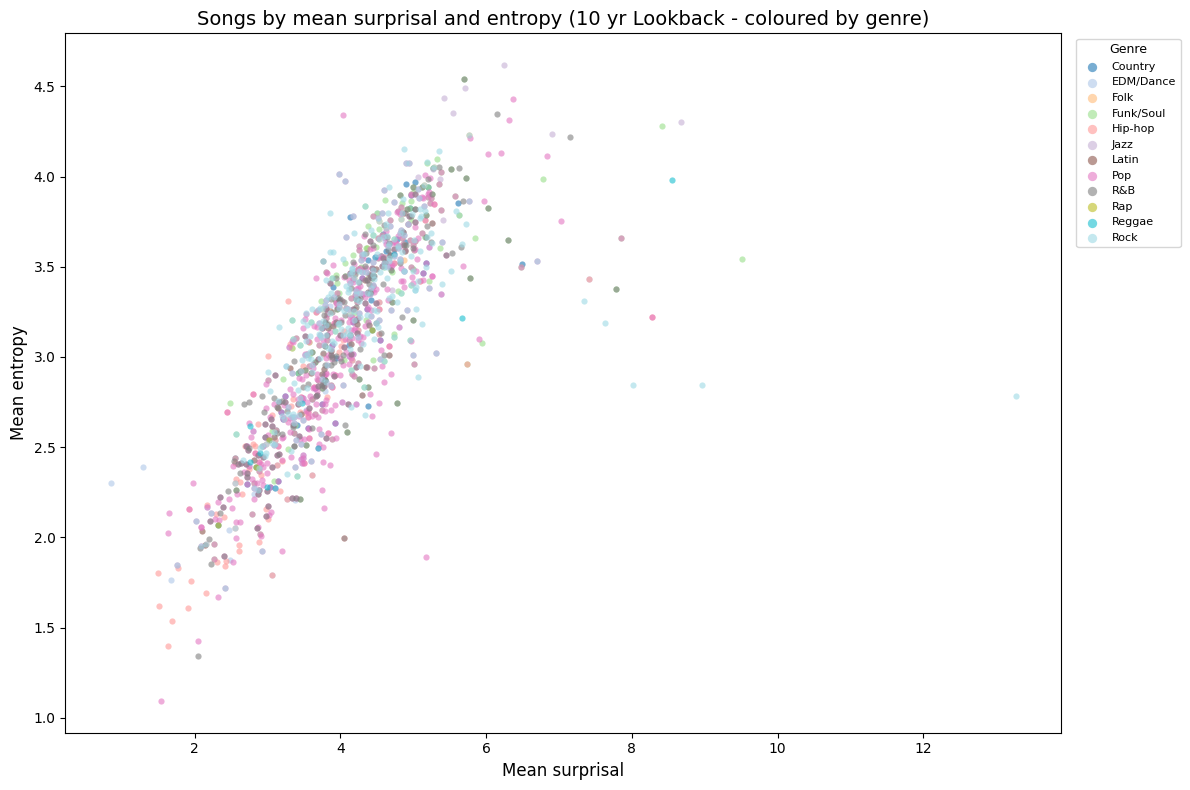

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

genre_cols = [
    "Genre (Broad 1)", "Genre (Broad 2)",
    # "Genre (Specific 1)", "Genre (Specific 2)", "Genre (Specific 3)"
]

# Melt to long format so each song-genre pair is one row, drop NaN genres
df_long = merged_all_songs_10yr_lookback.melt(
    id_vars=["year_position", "mean_surprisal", "mean_entropy"],
    value_vars=genre_cols,
    var_name="genre_col",
    value_name="genre"
).dropna(subset=["genre"])

# Get sorted unique genres and assign a color to each
unique_genres = sorted(df_long["genre"].unique())
cmap = plt.get_cmap("tab20", len(unique_genres))
genre_color = {genre: cmap(i) for i, genre in enumerate(unique_genres)}

fig, ax = plt.subplots(figsize=(12, 8))

# Plot each genre as its own layer so legend is clean
for genre in unique_genres:
    subset = df_long[df_long["genre"] == genre]
    ax.scatter(
        subset["mean_surprisal"],
        subset["mean_entropy"],
        color=genre_color[genre],
        label=genre,
        alpha=0.6,
        s=20,
        linewidths=0
    )

ax.set_xlabel("Mean surprisal", fontsize=12)
ax.set_ylabel("Mean entropy", fontsize=12)
ax.set_title("Songs by mean surprisal and entropy (10 yr Lookback - coloured by genre)", fontsize=14)

legend = ax.legend(
    title="Genre",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    fontsize=8,
    title_fontsize=9,
    frameon=True,
    markerscale=1.5
)

plt.tight_layout()
plt.show()


In [45]:
cols = ['year_position_raw', 'mean_surprisal', 'Genre (Broad 1)']

print("Cross Validation Outliers")

print(merged_cross_val_df[cols].sort_values(by='mean_surprisal', ascending=False).head(3))
print(merged_cross_val_df[cols].sort_values(by='mean_surprisal').head(3))

cols = ['song', 'mean_surprisal', 'Genre (Broad 1)']
print("5 Yr Lookback Outliers")
print(merged_all_songs_5yr_lookback[cols].sort_values(by='mean_surprisal', ascending=False).head(3))
print(merged_all_songs_5yr_lookback[cols].sort_values(by='mean_surprisal').head(3))

print("10 Yr Lookback Outliers")

print(merged_all_songs_10yr_lookback[cols].sort_values(by='mean_surprisal', ascending=False).head(3))
print(merged_all_songs_10yr_lookback[cols].sort_values(by='mean_surprisal').head(3))


Cross Validation Outliers
    year_position_raw  mean_surprisal Genre (Broad 1)
483         1962_01_1        7.569407            Jazz
748         1993_04_1        7.566777             R&B
671         1956_04_3        7.248999             R&B
    year_position_raw  mean_surprisal Genre (Broad 1)
362         2013_04_4        0.822900       EDM/Dance
167         2013_04_5        1.279061       EDM/Dance
486         2003_01_1        1.327483         Hip-hop
5 Yr Lookback Outliers
              song  mean_surprisal Genre (Broad 1)
4481  2014_02_misc       40.064836         Hip-hop
1296     1974_03_1       36.879334       Funk/Soul
885      1968_02_2       29.058200             Pop
           song  mean_surprisal Genre (Broad 1)
4651  2013_04_4        0.587108       EDM/Dance
4561  2013_04_4        0.588805       EDM/Dance
4735  2013_04_4        0.596173       EDM/Dance
10 Yr Lookback Outliers
          song  mean_surprisal Genre (Broad 1)
271  1979_01_3       13.263120            Rock
118  

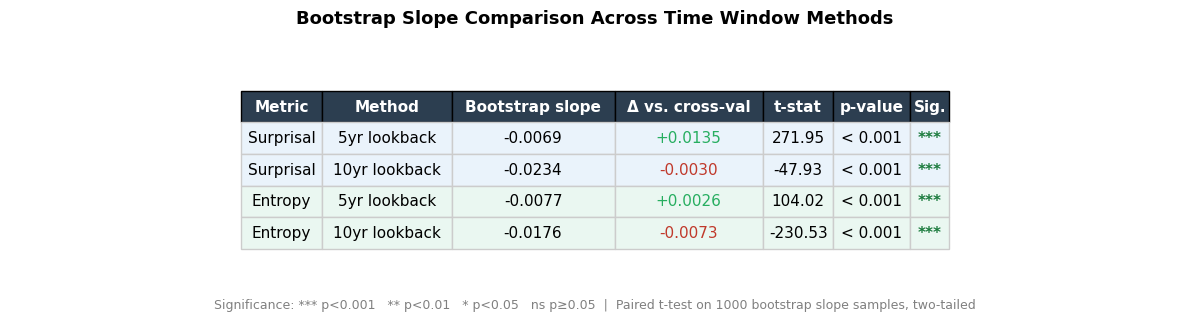

In [48]:
from scipy import stats
import numpy as np

np.random.seed(42)
N_BOOTSTRAP = 1000

def bootstrap_slopes(df, col, years_col="year", n=N_BOOTSTRAP):
    slopes = []
    data = df[[years_col, col]].dropna().copy()
    data[years_col] = pd.to_numeric(data[years_col], errors="coerce")  # fix here
    data = data.dropna()
    for _ in range(n):
        sample = data.sample(len(data), replace=True)
        years = sample[years_col].values
        values = sample[col].values
        slope = np.polyfit(years, values, deg=1)[0]
        slopes.append(slope)
    return np.array(slopes)

results = {}
for metric, col in [("Surprisal", "mean_surprisal"), ("Entropy", "mean_entropy")]:
    cv_slopes   = bootstrap_slopes(merged_cross_val_df, col)
    five_slopes = bootstrap_slopes(merged_all_songs_5yr_lookback, col)
    ten_slopes  = bootstrap_slopes(merged_all_songs_10yr_lookback, col)

    t_5v_cv,  p_5v_cv  = stats.ttest_rel(five_slopes, cv_slopes)
    t_10v_cv, p_10v_cv = stats.ttest_rel(ten_slopes,  cv_slopes)

    results[metric] = {
        "Cross-val slope":    cv_slopes.mean(),
        "5yr slope":          five_slopes.mean(),
        "10yr slope":         ten_slopes.mean(),
        "5yr_vs_cv_p":        p_5v_cv,
        "10yr_vs_cv_p":       p_10v_cv,
        "5yr_vs_cv_t":        t_5v_cv,
        "10yr_vs_cv_t":       t_10v_cv,
    }

# --- Table ---
def sig_stars(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "ns"

def fmt_p(p):
    return "< 0.001" if p < 0.001 else f"{p:.3f}"

rows = []
for metric in ["Surprisal", "Entropy"]:
    r = results[metric]
    cv_slope = r["Cross-val slope"]
    for method, slope_key, p_key, t_key in [
        ("5yr lookback",  "5yr slope",  "5yr_vs_cv_p",  "5yr_vs_cv_t"),
        ("10yr lookback", "10yr slope", "10yr_vs_cv_p", "10yr_vs_cv_t"),
    ]:
        slope = r[slope_key]
        p     = r[p_key]
        t     = r[t_key]
        diff  = slope - cv_slope
        rows.append([metric, method, f"{slope:.4f}", f"{diff:+.4f}", f"{t:.2f}", fmt_p(p), sig_stars(p)])

col_labels = ["Metric", "Method", "Bootstrap slope", "Δ vs. cross-val", "t-stat", "p-value", "Sig."]

fig, ax = plt.subplots(figsize=(12, 3.2))
ax.axis("off")

table = ax.table(cellText=rows, colLabels=col_labels, loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.8)

for col in range(len(col_labels)):
    cell = table[0, col]
    cell.set_facecolor("#2c3e50")
    cell.set_text_props(color="white", fontweight="bold")

row_colors  = {"Surprisal": "#eaf3fb", "Entropy": "#eaf7f1"}
sig_colors  = {"***": "#1a7a3c", "**": "#2ecc71", "*": "#f39c12", "ns": "#aaaaaa"}

for i, row in enumerate(rows):
    metric, stars = row[0], row[6]
    for col in range(len(col_labels)):
        cell = table[i + 1, col]
        cell.set_facecolor(row_colors[metric])
        cell.set_edgecolor("#cccccc")
        if col == 6:
            cell.set_text_props(color=sig_colors[stars], fontweight="bold")
        elif col == 3:
            cell.set_text_props(color="#c0392b" if float(row[3]) < 0 else "#27ae60")

table.auto_set_column_width(list(range(len(col_labels))))

fig.text(0.5, 0.02,
    "Significance: *** p<0.001   ** p<0.01   * p<0.05   ns p≥0.05  |  "
    f"Paired t-test on {N_BOOTSTRAP} bootstrap slope samples, two-tailed",
    ha="center", fontsize=9, color="gray")

plt.title("Bootstrap Slope Comparison Across Time Window Methods", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()